In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import scienceplots
plt.style.use(['science', 'no-latex'])

from FastBEMT import BEMT, BPM, Environment, F1A, Plotter, Propeller, Simulation
from FastBEMT.Aeroacoustics import circular_observer_array, uniform_observer_grid
from FastBEMT.Utils.DataLoader import load_propeller_dict
from FastBEMT.Aeroacoustics.Utils import third_octave_spectrum_to_overall_level

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch device: {DEVICE}")

PyTorch device: cuda


In [2]:
RPM = 7000.0
V_INF = 0.0
MAP_DOMAIN_SIZE = 5.0
MAP_GRID_SIZE = 30
MAP_METRIC = "oaspl"  # Use "oaspl" for the A-weighted map.
NUMBER_OF_REVOLUTIONS = 1
SOURCE_TIMESTEPS_PER_REVOLUTION = 360
BPM_TURBULENCE_LENGTH_SCALE = 1
BPM_TURBULENCE_INTENSITY = 1e-4
OBSERVER_BATCH_SIZE = 75

propeller_name, geometry = load_propeller_dict("../Data/New/10x7E")[0]

environment = Environment(
    a_inf=343.0,
    rho=1.225,
    mu=1.81e-5,
    p_ref=20.0e-6,
)
simulation = Simulation(
    revolutions=NUMBER_OF_REVOLUTIONS,
    timesteps_per_revolution=SOURCE_TIMESTEPS_PER_REVOLUTION,
    device=DEVICE,
)
propeller = Propeller(geometry, environment, simulation)
bemt = BEMT(
    propeller=propeller,
    environment=environment,
    rpm=RPM,
    v_inf=V_INF,
)
f1a = F1A(
    propeller=propeller,
    bemt=bemt,
)
performance = bemt.performance_for()
print(f"BEMT thrust: {performance.thrust:.3f} N")
print(f"BEMT torque: {performance.torque:.4f} N m")
print(f"F1A load shape: {tuple(f1a.loads.shape)} N/m")

c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\neuralfoil\main.py:171: RuntimeWarning: divide by zero encountered in log
  (np.log(Re) - 12.5) / 3.5,
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\aerosandbox\numpy\surrogate_model_tools.py:253: RuntimeWarning: invalid value encountered in divide
  return x / (1 + _np.exp(-beta * x))
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\neuralfoil\main.py:227: RuntimeWarning: invalid value encountered in matmul
  x = w @ x + np.reshape(b, (-1, 1))
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\aerosandbox\library\aerodynamics\viscous.py:142: RuntimeWarning: divide by zero encountered in scalar divide
  return 0.074 / Re_L ** (1 / 5)
C:\Users\PusinoDavide\FastBEMT\src\FastBEMT\Aerodynamics\Section.py:156: RuntimeWarning

BEMT thrust: 7.980 N
BEMT torque: 0.1393 N m
F1A load shape: (46, 3) N/m


In [3]:
map_observers = uniform_observer_grid(
    size=MAP_DOMAIN_SIZE,
    nx=MAP_GRID_SIZE,
    ny=MAP_GRID_SIZE,
)
f1a.run(
    observers=map_observers,
    observer_time_range=simulation.observer_time_range,
    num_observer_times=simulation.num_obs_times,
    observer_batch_size=OBSERVER_BATCH_SIZE,
)

map_ospl = f1a.ospl.cpu().numpy()
map_oaspl = f1a.oaspl.cpu().numpy()
map_level = map_oaspl if MAP_METRIC == "oaspl" else map_ospl
map_units = "dB(A)" if MAP_METRIC == "oaspl" else "dB"

print(f"F1A pressure shape: {tuple(f1a.p_tot.shape)}")
print(
    f"F1A map {MAP_METRIC.upper()} range: "
    f"{np.nanmin(map_level):.2f} to {np.nanmax(map_level):.2f} {map_units}"
)

F1A pressure shape: (900, 360)
F1A map OASPL range: -185.69 to 88.52 dB(A)


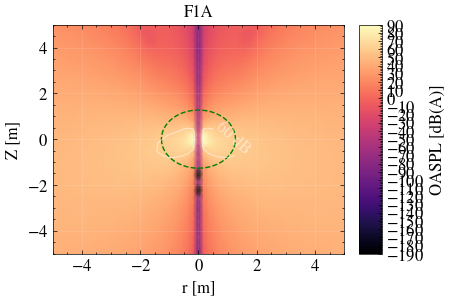

In [4]:
plotter = Plotter(propeller)
plotter.plot_acoustic_map(
    grid_size=MAP_GRID_SIZE,
    domain_size=MAP_DOMAIN_SIZE,
    noise_type="f1a",
    metric=MAP_METRIC,
    levels=map_level,
    figsize=(4.5, 3.0),
    cmap="magma",
    contour_levels=[60],
    mirror=True,
)

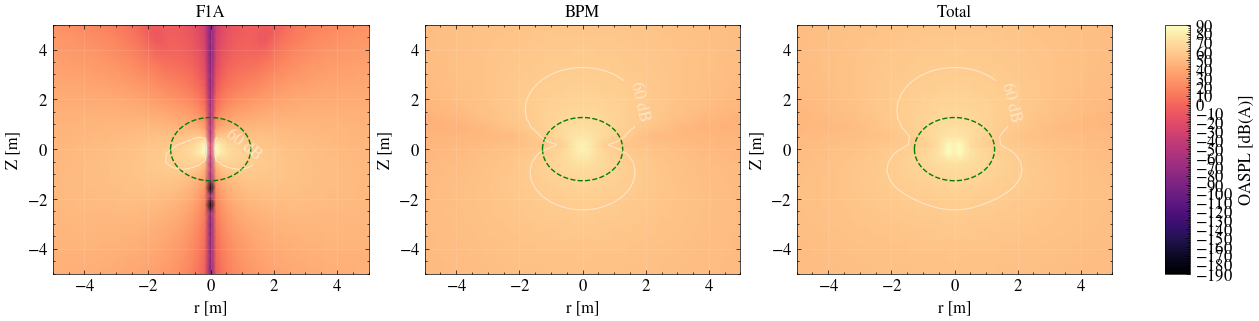

BPM map OASPL range: 43.74 to 82.34 dB(A)
Total map OASPL range: 47.11 to 89.00 dB(A)
Observer batch size: 75


In [5]:
bpm = BPM(
    propeller=propeller,
    bemt=bemt,
    kinematics=f1a.kinematics,
    lt=BPM_TURBULENCE_LENGTH_SCALE,
    i=BPM_TURBULENCE_INTENSITY,
)
bpm.run(
    observers=map_observers,
    observer_time_range=simulation.observer_time_range,
    num_observer_times=simulation.num_obs_times,
    observer_batch_size=OBSERVER_BATCH_SIZE,
)

map_bpm_ospl = bpm.ospl.cpu().numpy()
map_bpm_oaspl = bpm.oaspl.cpu().numpy()
map_bpm_level = map_bpm_oaspl if MAP_METRIC == "oaspl" else map_bpm_ospl
map_total_level = Plotter.combine_level_maps(map_level, map_bpm_level)

plotter.plot_acoustic_maps(
    {
        "F1A": map_level,
        "BPM": map_bpm_level,
        "Total": map_total_level,
    },
    grid_size=MAP_GRID_SIZE,
    domain_size=MAP_DOMAIN_SIZE,
    metric=MAP_METRIC,
    contour_levels=60,
    columns=3,
    cmap="magma",
)

print(
    f"BPM map {MAP_METRIC.upper()} range: "
    f"{np.nanmin(map_bpm_level):.2f} to {np.nanmax(map_bpm_level):.2f} {map_units}"
)
print(
    f"Total map {MAP_METRIC.upper()} range: "
    f"{np.nanmin(map_total_level):.2f} to {np.nanmax(map_total_level):.2f} {map_units}"
)
print(f"Observer batch size: {OBSERVER_BATCH_SIZE}")


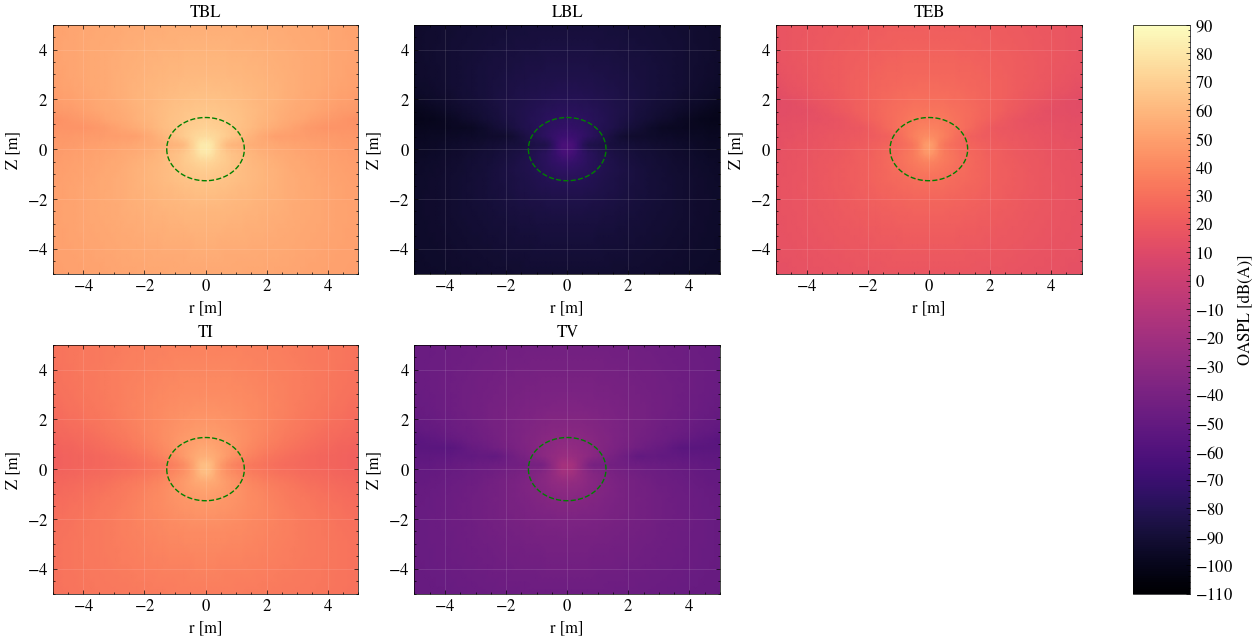

In [6]:
component_level_maps = {}
for component_name, component_spl in bpm.component_spl.items():
    component_level = third_octave_spectrum_to_overall_level(
        component_spl,
        bpm.frequencies,
        weighted=MAP_METRIC == "oaspl",
        frequency_dim=1,
    )
    component_level_maps[component_name.upper()] = component_level.cpu().numpy()

plotter.plot_acoustic_maps(
    component_level_maps,
    grid_size=MAP_GRID_SIZE,
    domain_size=MAP_DOMAIN_SIZE,
    metric=MAP_METRIC,
    columns=3,
    cmap="magma",
)


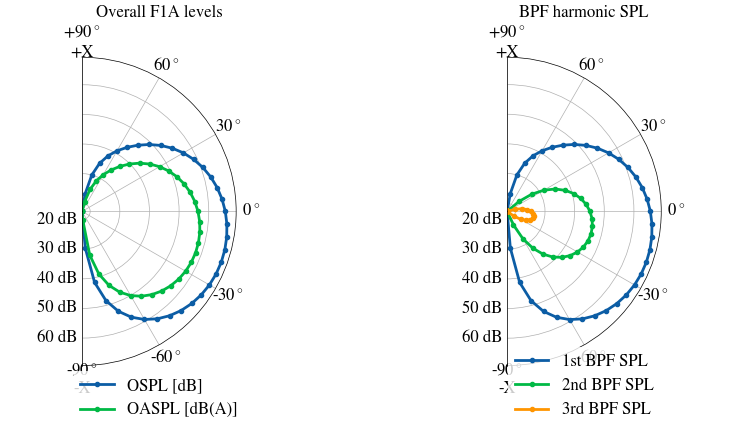

In [7]:
POLAR_RADIUS = 1.88
POLAR_OBSERVERS = 37
elevation_deg = np.linspace(-90.0, 90.0, POLAR_OBSERVERS)
polar_observers = circular_observer_array(
    radius=POLAR_RADIUS,
    n_points=POLAR_OBSERVERS,
)

f1a.run(
    observers=polar_observers,
    observer_time_range=simulation.observer_time_range,
    num_observer_times=simulation.num_obs_times,
)

polar_ospl = f1a.ospl.cpu().numpy()
polar_oaspl = f1a.oaspl.cpu().numpy()
polar_frequency = f1a.frequencies.cpu().numpy()
polar_spl = f1a.spl.cpu().numpy()

blade_passing_frequency = RPM * propeller.n_blades / 60.0
bpf_orders = np.array([1.0, 2.0, 3.0])
bpf_indices = np.array(
    [
        int(np.argmin(np.abs(polar_frequency - order * blade_passing_frequency)))
        for order in bpf_orders
    ]
)
bpf_spl = polar_spl[:, bpf_indices]

overall_curves = {
    "OSPL [dB]": polar_ospl,
    "OASPL [dB(A)]": polar_oaspl,
}
bpf_curves = {
    "1st BPF SPL": bpf_spl[:, 0],
    "2nd BPF SPL": bpf_spl[:, 1],
    "3rd BPF SPL": bpf_spl[:, 2],
}
theta = np.deg2rad(elevation_deg)


def plot_level_polar(axis, curves, title):
    peak = max(float(np.max(values)) for values in curves.values())
    floor = peak - 50.0

    for label, values in curves.items():
        radius = np.maximum(values, floor) - floor
        axis.plot(
            theta,
            radius,
            linewidth=2.0,
            marker="o",
            markersize=3,
            label=label,
        )

    axis.set_title(title, fontsize=12)
    axis.set_theta_zero_location("E")
    axis.set_theta_direction(1)
    axis.set_thetamin(-90.0)
    axis.set_thetamax(90.0)
    axis.set_xticks(
        np.deg2rad([-90.0, -60.0, -30.0, 0.0, 30.0, 60.0, 90.0])
    )
    axis.set_xticklabels(
        [
            r"-90$^\circ$" + "\n-X",
            r"-60$^\circ$",
            r"-30$^\circ$",
            r"0$^\circ$",
            r"30$^\circ$",
            r"60$^\circ$",
            r"+90$^\circ$" + "\n+X",
        ]
    )
    level_ticks = np.arange(
        np.ceil(floor / 10.0) * 10.0,
        peak + 1.0,
        10.0,
    )
    axis.set_yticks(level_ticks - floor)
    axis.set_yticklabels([f"{level:.0f} dB" for level in level_ticks])
    axis.tick_params(axis="both", labelsize=12)
    axis.set_ylim(0.0, peak + 2.0 - floor)
    axis.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, -0.22),
        ncol=1,
        frameon=True,
        edgecolor="none",
        fontsize=12,
    )


figure, polar_axes = plt.subplots(
    1,
    2,
    figsize=(8.5, 4.4),
    subplot_kw={"projection": "polar"},
    constrained_layout=True,
)
plot_level_polar(polar_axes[0], overall_curves, "Overall F1A levels")
plot_level_polar(polar_axes[1], bpf_curves, "BPF harmonic SPL")
plt.show()

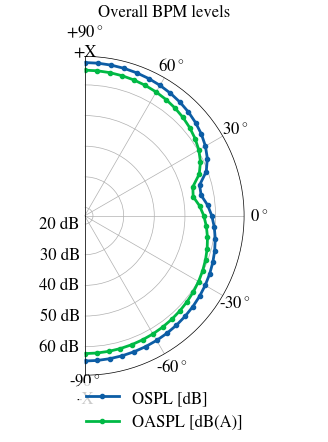

BPM spectrum shape: (37, 30)
BPM components: tbl, lbl, teb, ti, tv
BPM observer samples: 360


In [8]:
bpm = BPM(
    propeller=propeller,
    bemt=bemt,
    kinematics=f1a.kinematics,
    lt=BPM_TURBULENCE_LENGTH_SCALE,
    i=BPM_TURBULENCE_INTENSITY,
)
bpm.run(
    observers=polar_observers,
    observer_time_range=simulation.observer_time_range,
    num_observer_times=simulation.num_obs_times,
    observer_batch_size=OBSERVER_BATCH_SIZE,
)

bpm_overall_curves = {
    "OSPL [dB]": bpm.ospl.cpu().numpy(),
    "OASPL [dB(A)]": bpm.oaspl.cpu().numpy(),
}

figure, axis = plt.subplots(
    1,
    1,
    figsize=(4.5, 4.4),
    subplot_kw={"projection": "polar"},
    constrained_layout=True,
)
plot_level_polar(axis, bpm_overall_curves, "Overall BPM levels")
plt.show()

print(f"BPM spectrum shape: {tuple(bpm.spl.shape)}")
print(f"BPM components: {', '.join(bpm.component_spl.keys())}")
print(f"BPM observer samples: {bpm.num_observer_times}")


c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\neuralfoil\main.py:171: RuntimeWarning: divide by zero encountered in log
  (np.log(Re) - 12.5) / 3.5,
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\aerosandbox\numpy\surrogate_model_tools.py:253: RuntimeWarning: invalid value encountered in divide
  return x / (1 + _np.exp(-beta * x))
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\neuralfoil\main.py:227: RuntimeWarning: invalid value encountered in matmul
  x = w @ x + np.reshape(b, (-1, 1))
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\aerosandbox\library\aerodynamics\viscous.py:142: RuntimeWarning: divide by zero encountered in scalar divide
  return 0.074 / Re_L ** (1 / 5)
C:\Users\PusinoDavide\FastBEMT\src\FastBEMT\Aerodynamics\Section.py:156: RuntimeWarning

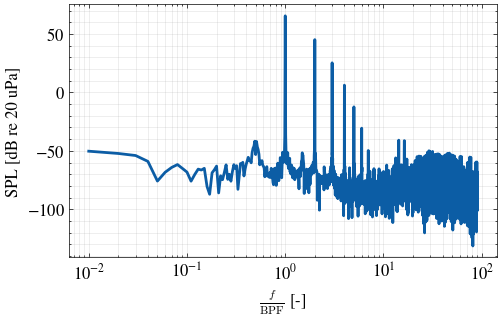

Pressure samples: 18000
Observer rotations: 50
Blade-passing frequency: 233.333 Hz
Frequency resolution: 2.333 Hz
BPF resolution: 0.010
Plane observer position: [0.   0.   1.88]


In [9]:
SPECTRUM_ROTATIONS = 50
SPECTRUM_POINTS_PER_ROTATION = 360
PLANE_RADIUS = 1.88
plane_observer = np.array([[0.0, 0.0, PLANE_RADIUS]], dtype=np.float32)

_, spectrum_geometry = load_propeller_dict("../Data/New/10x7E")[0]

spectrum_simulation = Simulation(
    revolutions=SPECTRUM_ROTATIONS,
    timesteps_per_revolution=SPECTRUM_POINTS_PER_ROTATION,
    device=DEVICE,
)
spectrum_propeller = Propeller(
    spectrum_geometry,
    environment,
    spectrum_simulation,
)
spectrum_bemt = BEMT(
    propeller=spectrum_propeller,
    environment=environment,
    rpm=RPM,
    v_inf=V_INF,
)

spectrum_f1a = F1A(
    propeller=spectrum_propeller,
    bemt=spectrum_bemt,
)
spectrum_f1a.run(
    observers=plane_observer,
    observer_time_range=spectrum_simulation.duration,
    num_observer_times=spectrum_simulation.num_obs_times,
    observer_batch_size=OBSERVER_BATCH_SIZE,
)

plane_frequency = spectrum_f1a.frequencies[1:].cpu().numpy()
plane_spl = spectrum_f1a.spl[0, 1:].cpu().numpy()
blade_passing_frequency = RPM * spectrum_propeller.n_blades / 60.0
plane_bpf_order = plane_frequency / blade_passing_frequency

figure, axis = plt.subplots(figsize=(5.0, 3.2), constrained_layout=True)
axis.semilogx(plane_bpf_order, plane_spl, linewidth=2.0)
axis.set_xlabel(r"$\frac{f}{\mathrm{BPF}}$ [-]", fontsize=12)
axis.set_ylabel("SPL [dB re 20 uPa]", fontsize=12)
axis.tick_params(axis="both", labelsize=12)
axis.grid(True, which="both", alpha=0.3)
plt.show()

frequency_resolution = 1.0 / spectrum_f1a.observer_time_range
bpf_resolution = frequency_resolution / blade_passing_frequency
print(f"Pressure samples: {spectrum_f1a.p_tot.shape[1]}")
print(f"Observer rotations: {spectrum_f1a.observer_rotations}")
print(f"Blade-passing frequency: {blade_passing_frequency:.3f} Hz")
print(f"Frequency resolution: {frequency_resolution:.3f} Hz")
print(f"BPF resolution: {bpf_resolution:.3f}")
print(f"Plane observer position: {plane_observer[0]}")

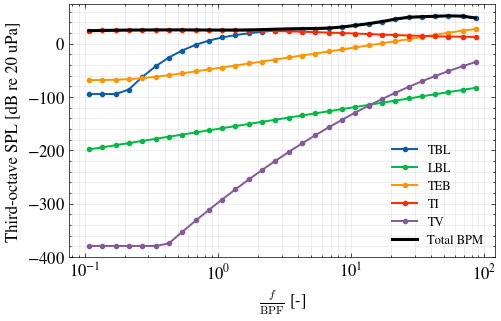

BPM source samples in one rotation: 360
BPM observer samples in one rotation: 360
Plane observer position: [0.   0.   1.88]


In [10]:
spectrum_bpm = BPM(
    propeller=spectrum_propeller,
    bemt=spectrum_bemt,
    kinematics=spectrum_f1a.kinematics,
    lt=BPM_TURBULENCE_LENGTH_SCALE,
    i=BPM_TURBULENCE_INTENSITY,
)
spectrum_bpm.run(
    observers=plane_observer,
    observer_time_range=spectrum_simulation.observer_time_range,
    num_observer_times=spectrum_simulation.num_obs_times,
    observer_batch_size=OBSERVER_BATCH_SIZE,
)

bpm_frequency = spectrum_bpm.frequencies.cpu().numpy()
bpm_bpf_order = bpm_frequency / blade_passing_frequency

figure, axis = plt.subplots(figsize=(5.0, 3.2), constrained_layout=True)
for component_name, component_spl in spectrum_bpm.component_spl.items():
    axis.semilogx(
        bpm_bpf_order,
        component_spl[0].cpu().numpy(),
        linewidth=1.4,
        marker="o",
        markersize=3,
        label=component_name.upper(),
    )
axis.semilogx(
    bpm_bpf_order,
    spectrum_bpm.spl[0].cpu().numpy(),
    color="black",
    linewidth=2.2,
    label="Total BPM",
)
axis.set_xlabel(r"$\frac{f}{\mathrm{BPF}}$ [-]", fontsize=12)
axis.set_ylabel("Third-octave SPL [dB re 20 uPa]", fontsize=12)
axis.tick_params(axis="both", labelsize=12)
axis.grid(True, which="both", alpha=0.3)
axis.legend(fontsize=9)
plt.show()

print(f"BPM source samples in one rotation: {spectrum_bpm.nt}")
print(f"BPM observer samples in one rotation: {spectrum_bpm.num_observer_times}")
print(f"Plane observer position: {plane_observer[0]}")
